# Week 2: Quantum Circuit Simulation
This script demonstrates how to create a single-qubit circuit, 
visualize it, and execute it using the StatevectorSampler.

In [1]:
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram, plot_bloch_multivector
import matplotlib.pyplot as plt

## 1. Circuit Initialization

In [2]:
# Create a Quantum Circuit with 1 qubit and 1 classical bit
qc = QuantumCircuit(1, 1)

In [3]:
# Apply an Identity gate (performs no operation, qubit remains in |0>)
qc.id(0)

# Optional Gates (uncomment to change the state)
# qc.h(0)  # Put qubit in superposition
# qc.x(0)  # Flip qubit to |1>

# 2. Visualization

### Text-based circuit diagram:

In [4]:
print(qc)

     ┌───┐
  q: ┤ I ├
     └───┘
c: 1/═════
          


### Draw the circuit using Matplotlib

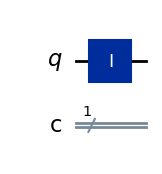

In [5]:
qc.draw('mpl')

### Print qubit and clbit objects for debugging

In [6]:
for qubit in qc.qubits:
    print(f"Qubit object: {qubit}")

for clbit in qc.clbits:
    print(f"Classical bit object: {clbit}")

Qubit object: <Qubit register=(1, "q"), index=0>
Classical bit object: <Clbit register=(1, "c"), index=0>


### 3. State Analysis
View the qubit's position on the Bloch Sphere before measurement

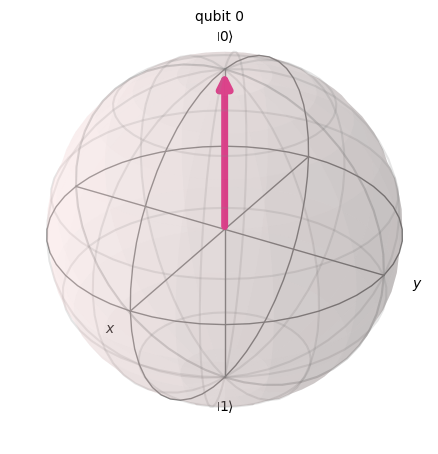

In [7]:
state = Statevector.from_instruction(qc)
plot_bloch_multivector(state)

## 4. Execution (Sampling)

Initialize the Sampler primitive

In [8]:
sampler = StatevectorSampler()

In [9]:
# Run the job for 1024 shots to get statistical results
# Note: In Qiskit 1.0+, we wrap the circuit in a list (as a PUB)
job = sampler.run([qc], shots=1024)

## 5. Results Processing

### Extract the result for the first (and only) PUB

In [10]:
result = job.result()[0]

### Retrieve measurement counts from the classical register 'c'

In [11]:
counts = result.data.c.get_counts()
print(f"Measurement counts: {counts}")

Measurement counts: {'0': 1024}


### Plot the distribution of results

In [ ]:
plot_histogram(counts)